In [1]:
import pandas as pd
import csv
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import OrdinalEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import joblib

In [2]:
#Open database,skipping the shifted rows
books = pd.read_csv("../Data/Raw/books.csv", on_bad_lines="skip")
books

,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...,...
11118,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9781560254416,eng,512,156,20,12/21/2004,Da Capo Press
11119,45633,You Bright and Risen Angels,William T. Vollmann,4.08,0140110879,9780140110876,eng,635,783,56,12/1/1988,Penguin Books
11120,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,0140131965,9780140131963,eng,415,820,95,8/1/1993,Penguin Books
11121,45639,Poor People,William T. Vollmann,3.72,0060878827,9780060878825,eng,434,769,139,2/27/2007,Ecco


In [3]:
#Fix the shifted rows who are seperated by a comma(4 rows)
input_file  = "../Data/Raw/books.csv"
output_file = "../Data/Clean/clean_books.csv"
 
with open(input_file, "r", encoding="utf-8", newline="") as f_in, open(
    output_file, "w", encoding="utf-8", newline=""
) as f_out:
  reader = csv.reader(f_in)
  writer = csv.writer(f_out)
 
  header = next(reader)
  expected_len = len(header)
  writer.writerow(header)
 
  for row in reader:
    if len(row) > expected_len:
      excess = len(row) - expected_len
      fixed_row = row[:2] + [",".join(row[2 : 2 + excess + 1])] + row[2 + excess + 1 :]
      writer.writerow(fixed_row)
    else:
      writer.writerow(row)

In [4]:
# New database with fixed rows
clean_books = pd.read_csv("../Data/Clean/clean_books.csv")
clean_books


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,1,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,0439785960,9780439785969,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,2,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,0439358078,9780439358071,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,4,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,0439554896,9780439554893,eng,352,6333,244,11/1/2003,Scholastic
3,5,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,043965548X,9780439655484,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,8,Harry Potter Boxed Set Books 1-5 (Harry Potte...,J.K. Rowling/Mary GrandPré,4.78,0439682584,9780439682589,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...,...,...,...
11122,45631,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,1560254416,9781560254416,eng,512,156,20,12/21/2004,Da Capo Press
11123,45633,You Bright and Risen Angels,William T. Vollmann,4.08,0140110879,9780140110876,eng,635,783,56,12/1/1988,Penguin Books
11124,45634,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,0140131965,9780140131963,eng,415,820,95,8/1/1993,Penguin Books
11125,45639,Poor People,William T. Vollmann,3.72,0060878827,9780060878825,eng,434,769,139,2/27/2007,Ecco


In [5]:
#checking for leading spaces in the rest of the dataset
clean_books = clean_books.apply(lambda c: c.str.strip() if c.dtype == "object" else c)
for col in clean_books.select_dtypes(include="object").columns:
    s = clean_books[col].astype(str)
    print(f"{col:18s} leading_spaces remaining: {(s != s.str.strip()).sum()}")

title              leading_spaces remaining: 1
authors            leading_spaces remaining: 0
isbn               leading_spaces remaining: 0
language_code      leading_spaces remaining: 0
publication_date   leading_spaces remaining: 0
publisher          leading_spaces remaining: 0


C:\Users\abdel\AppData\Local\Temp\ipykernel_8944\1355093420.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean_books.select_dtypes(include="object").columns:


In [6]:
#checking for double spaces in string columns and removing them
for col in ['title', 'authors', 'publisher']:
    clean_books[col] = clean_books[col].str.replace(r'\s+', ' ', regex=True).str.strip()
for col in clean_books.select_dtypes(include="object").columns:
    s = clean_books[col].astype(str)
    doubles  = s.str.contains(r"\s{2,}", regex=True).sum()
    print(f"{col:18s} doubles_spaces: {doubles:5d}")

title              doubles_spaces:     0
authors            doubles_spaces:     0
isbn               doubles_spaces:     0
language_code      doubles_spaces:     0
publication_date   doubles_spaces:     0
publisher          doubles_spaces:     0


C:\Users\abdel\AppData\Local\Temp\ipykernel_8944\859651040.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in clean_books.select_dtypes(include="object").columns:


In [7]:
#check for duplicates for the dataset
duplicates = clean_books[clean_books.duplicated()]
print("number of identical rows:", len(duplicates))


number of identical rows: 0


In [8]:
#check for duplicated authors and titles,we will keep them
duplicates = clean_books[clean_books.duplicated(subset=['title', 'authors'], keep = False)]
print ("Number of identical titles and author name", len(duplicates))
duplicates.head(10)
 

Number of identical titles and author name 591


,bookID,title,authors,average_rating,isbn,isbn13,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
9,14,The Hitchhiker's Guide to the Galaxy (Hitchhik...,Douglas Adams,4.22,1400052920,9781400052929,eng,215,4930,460,8/3/2004,Crown
12,21,A Short History of Nearly Everything,Bill Bryson,4.21,076790818X,9780767908184,eng,544,248558,9396,9/14/2004,Broadway Books
13,22,Bill Bryson's African Diary,Bill Bryson,3.44,0767915062,9780767915069,eng,55,7270,499,12/3/2002,Broadway Books
22,31,The Lord of the Rings (The Lord of the Rings #...,J.R.R. Tolkien,4.50,0618517650,9780618517657,eng,1184,1710,91,10/21/2004,Houghton Mifflin Harcourt
23,34,The Fellowship of the Ring (The Lord of the Ri...,J.R.R. Tolkien,4.36,0618346252,9780618346257,eng,398,2128944,13670,9/5/2003,Houghton Mifflin Harcourt
39,67,The Known World,Edward P. Jones,3.83,0061159174,9780061159176,eng,388,29686,2626,8/29/2006,Amistad
41,69,The Known World,Edward P. Jones,3.83,0060749911,9780060749910,eng,576,22,3,6/15/2004,Harper
65,103,God Emperor of Dune (Dune Chronicles #4),Frank Herbert,3.84,0441294677,9780441294671,eng,423,2785,166,6/15/1987,Ace Books
69,109,Heretics of Dune (Dune Chronicles #5),Frank Herbert,3.86,0399128980,9780399128981,eng,480,272,20,4/16/1984,Putnam
71,117,Heretics of Dune (Dune Chronicles #5),Frank Herbert,3.86,0441328008,9780441328000,eng,471,45388,644,8/15/1987,Ace Books


In [9]:
#check for missing data
clean_books.isnull().sum()

bookID                0
title                 0
authors               0
average_rating        0
isbn                  0
isbn13                0
language_code         0
  num_pages           0
ratings_count         0
text_reviews_count    0
publication_date      0
publisher             0
dtype: int64

In [10]:
#checking for leading spaces in headers and removing them
clean_books.columns = clean_books.columns.str.strip()
clean_books.columns.tolist()

['bookID',
 'title',
 'authors',
 'average_rating',
 'isbn',
 'isbn13',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publication_date',
 'publisher']

In [11]:
#Droping rows with average_ratings of 0
clean_books = clean_books.loc[clean_books["average_rating"] > 0]
zero_rating= (clean_books["average_rating"] == 0).any()
print("Is there a zero average_rating?:", zero_rating)
print("Number of rows with valid average_rating:",len(clean_books))


Is there a zero average_rating?: False
Number of rows with valid average_rating: 11101


In [12]:
#Droping the columns 'isbn' and 'isbn13'
clean_books = clean_books.drop(columns=['bookID','isbn','isbn13'])
clean_books

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,publication_date,publisher
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,eng,652,2095690,27591,9/16/2006,Scholastic Inc.
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,eng,870,2153167,29221,9/1/2004,Scholastic Inc.
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,eng,352,6333,244,11/1/2003,Scholastic
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,eng,435,2339585,36325,5/1/2004,Scholastic Inc.
4,Harry Potter Boxed Set Books 1-5 (Harry Potter...,J.K. Rowling/Mary GrandPré,4.78,eng,2690,41428,164,9/13/2004,Scholastic
...,...,...,...,...,...,...,...,...,...
11122,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,eng,512,156,20,12/21/2004,Da Capo Press
11123,You Bright and Risen Angels,William T. Vollmann,4.08,eng,635,783,56,12/1/1988,Penguin Books
11124,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,eng,415,820,95,8/1/1993,Penguin Books
11125,Poor People,William T. Vollmann,3.72,eng,434,769,139,2/27/2007,Ecco


In [13]:
#check data type for each column
clean_books.dtypes

title                     str
authors                   str
average_rating        float64
language_code             str
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publication_date          str
publisher                 str
dtype: object

#trying to convert publication date to dateime format but error because of wrong data
clean_books["publication_date"]= pd.to_datetime(clean_books["publication_date"], format='mixed')
clean_books["publication_date"] = clean_books["publication_date"].dt.year
clean_books["publication_date"]

In [14]:
#splitting month,day and year and keeping only year to minimize inacurracies
clean_books[["month","day","year"]]= clean_books["publication_date"].str.split("/", expand= True)
clean_books = clean_books.drop(columns=['publication_date','month','day'])
clean_books

,title,authors,average_rating,language_code,num_pages,ratings_count,text_reviews_count,publisher,year
0,Harry Potter and the Half-Blood Prince (Harry ...,J.K. Rowling/Mary GrandPré,4.57,eng,652,2095690,27591,Scholastic Inc.,2006
1,Harry Potter and the Order of the Phoenix (Har...,J.K. Rowling/Mary GrandPré,4.49,eng,870,2153167,29221,Scholastic Inc.,2004
2,Harry Potter and the Chamber of Secrets (Harry...,J.K. Rowling,4.42,eng,352,6333,244,Scholastic,2003
3,Harry Potter and the Prisoner of Azkaban (Harr...,J.K. Rowling/Mary GrandPré,4.56,eng,435,2339585,36325,Scholastic Inc.,2004
4,Harry Potter Boxed Set Books 1-5 (Harry Potter...,J.K. Rowling/Mary GrandPré,4.78,eng,2690,41428,164,Scholastic,2004
...,...,...,...,...,...,...,...,...,...
11122,Expelled from Eden: A William T. Vollmann Reader,William T. Vollmann/Larry McCaffery/Michael He...,4.06,eng,512,156,20,Da Capo Press,2004
11123,You Bright and Risen Angels,William T. Vollmann,4.08,eng,635,783,56,Penguin Books,1988
11124,The Ice-Shirt (Seven Dreams #1),William T. Vollmann,3.96,eng,415,820,95,Penguin Books,1993
11125,Poor People,William T. Vollmann,3.72,eng,434,769,139,Ecco,2007


In [15]:
#renaming year to publication_year 
clean_books= clean_books.rename(columns={'year': 'publication_year'})
list(clean_books)

['title',
 'authors',
 'average_rating',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publisher',
 'publication_year']

In [16]:
#Converting publication year to integer
clean_books["publication_year"]= clean_books["publication_year"].astype(int)
clean_books.dtypes

title                     str
authors                   str
average_rating        float64
language_code             str
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publisher                 str
publication_year        int64
dtype: object

In [17]:
#Check if book is audiobook or printed
publication_keyword = r'audio|tantor|listening library|recorded books|books on tape|highbridge|your coach'
title_keyword = r'audio|unabridged|abridged|\bcd\b|audiobook|spoken|cassette'

clean_books['is_audiobook'] = (
    clean_books['publisher'].str.contains(publication_keyword, case=False) |
    clean_books['title'].str.contains(title_keyword, case=False)
).astype(int)
print("audiobooks flagged:", clean_books['is_audiobook'].sum())
clean_books[clean_books['is_audiobook'] == 1][['title','publisher','is_audiobook']].sample(15)

audiobooks flagged: 232


,title,publisher,is_audiobook
2255,Animales No Se Visten Los (Animals Should Defi...,Live Oak Media,1
1051,Anne of Avonlea,Blackstone Audiobooks,1
4947,Antibodies,AudioText,1
7017,Haunted Castle on Hallows Eve (Magic Tree Hous...,Listening Library (Audio),1
708,In Cold Blood,Random House Audio,1
10025,Metro Girl (Alex Barnaby #1),HarperAudio,1
10840,The Silver Pigs,BBC Audiobooks,1
10973,Howards End,Blackstone Audiobooks,1
1266,Fahrenheit 451,Blackstone Audiobooks,1
8522,The Monkey,Random House Audio,1


In [18]:
#Replacing number of pages for non audiobooks by the median for books with num_page=0
median_pages = clean_books.loc[clean_books["num_pages"] > 0,"num_pages"].median()
print_books_missing_pages = (clean_books["num_pages"] == 0) & (clean_books["is_audiobook"] == 0)
clean_books.loc[print_books_missing_pages, "num_pages"] = median_pages
print("Audiobooks with zero pages:", clean_books[clean_books["num_pages"]== 0]["is_audiobook"].sum())
n_affected = print_books_missing_pages.sum()
print(f"The median number of pages is {median_pages:.0f} and {n_affected} books were affected")

Audiobooks with zero pages: 52
The median number of pages is 302 and 24 books were affected


In [19]:
#Changing num_pages back to integer
clean_books["num_pages"] = clean_books["num_pages"].astype(int)
clean_books.dtypes

title                     str
authors                   str
average_rating        float64
language_code             str
num_pages               int64
ratings_count           int64
text_reviews_count      int64
publisher                 str
publication_year        int64
is_audiobook            int64
dtype: object

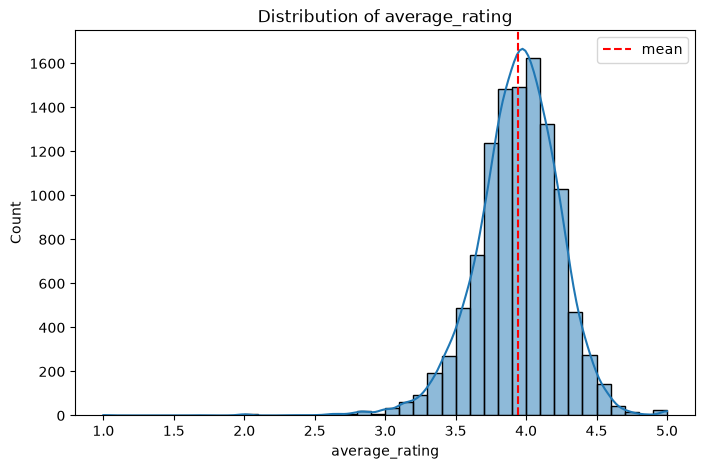

In [20]:
# Hystogram plot of "average_rating"
plt.figure(figsize=(8,5))
sns.histplot(clean_books['average_rating'], bins=40, kde=True)
plt.axvline(clean_books['average_rating'].mean(), color='red', ls='--', label='mean')
plt.title('Distribution of average_rating'); plt.legend()
plt.show()

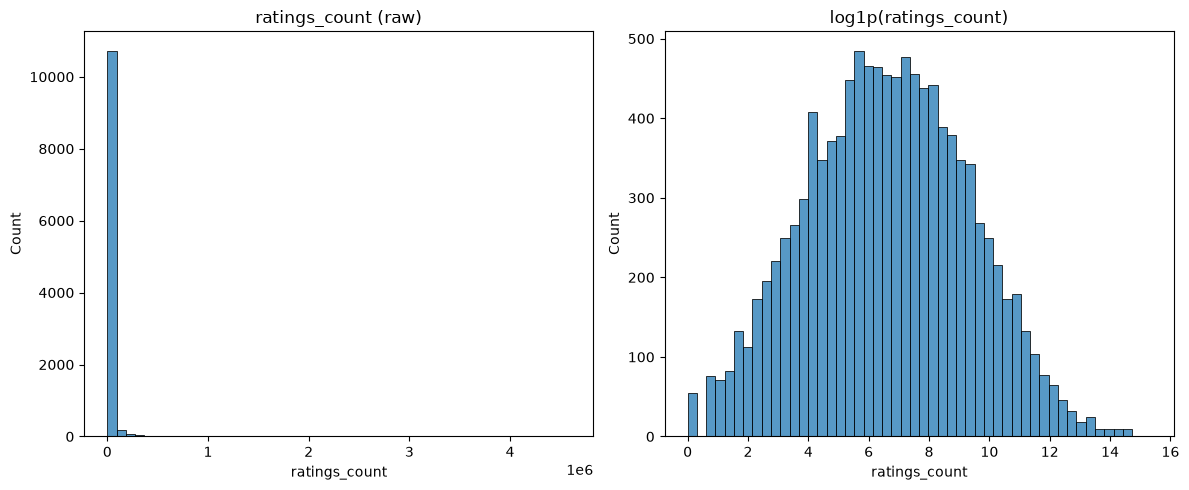

In [21]:
# Plotting "rating_count" raw vs log
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(clean_books['ratings_count'], bins=50, ax=axes[0])
axes[0].set_title('ratings_count (raw)')
sns.histplot(np.log1p(clean_books['ratings_count']), bins=50, ax=axes[1])
axes[1].set_title('log1p(ratings_count)')
plt.tight_layout(); plt.show()

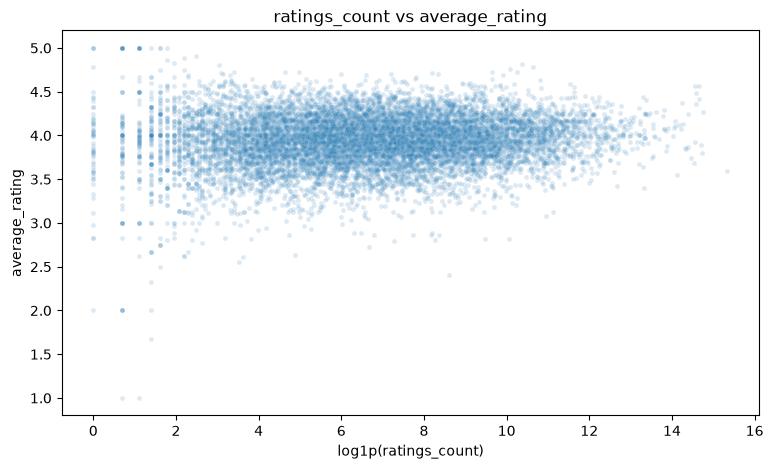

In [22]:
# Plotting average_rating vs rating_count(with log of rating_counts)
plt.figure(figsize=(9,5))
sns.scatterplot(x=np.log1p(clean_books['ratings_count']),
                y=clean_books['average_rating'], alpha=0.15, s=12)
plt.xlabel('log1p(ratings_count)'); plt.ylabel('average_rating')
plt.title('ratings_count vs average_rating')
plt.show()

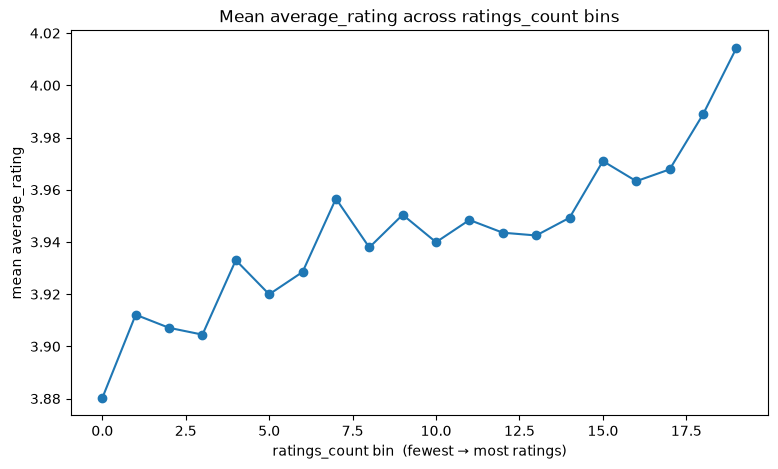

In [23]:
# Binned plotting of avaerage_rating and rating_count(here the books are parted in equal group sizes)
# 20 equal-size groups by ratings_count
clean_books['ratings_count_bin'] = pd.qcut(clean_books['ratings_count'], q=20) 
binned = clean_books.groupby('ratings_count_bin', observed=True)['average_rating'].mean()

plt.figure(figsize=(9,5))
plt.plot(range(len(binned)), binned.values, marker='o')
plt.xlabel('ratings_count bin  (fewest → most ratings)')
plt.ylabel('mean average_rating')
plt.title('Mean average_rating across ratings_count bins')
plt.show()

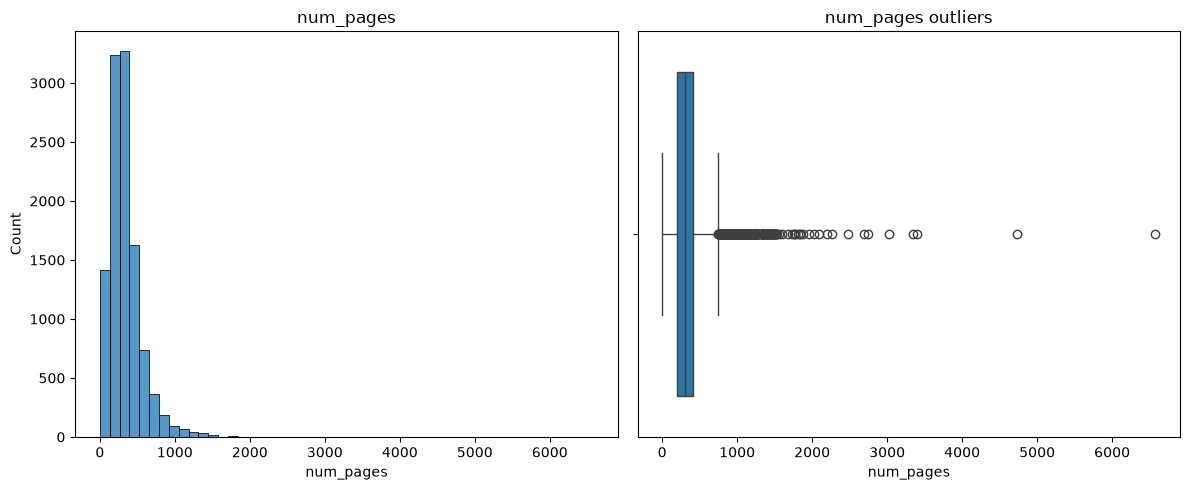

In [24]:
# Hystogram plotting of num_pages showing its distribution and boxplot of num_pages to display the outliers
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(clean_books['num_pages'], bins=50, ax=axes[0]); axes[0].set_title('num_pages')
sns.boxplot(x=clean_books['num_pages'], ax=axes[1]);         axes[1].set_title('num_pages outliers')
plt.tight_layout(); plt.show()

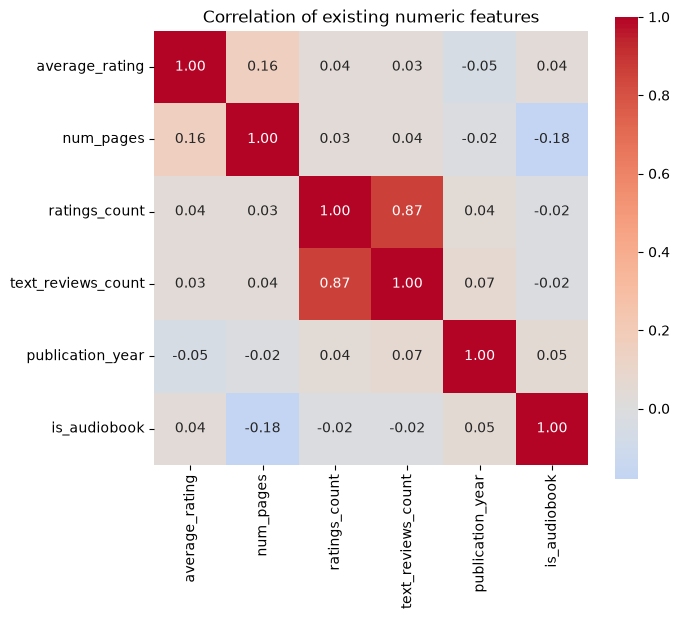

In [25]:
#Correlation heatmap before feature engineering
num_cols = ['average_rating', 'num_pages', 'ratings_count',
            'text_reviews_count', 'publication_year', 'is_audiobook']
plt.figure(figsize=(7,6))
sns.heatmap(clean_books[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True)
plt.title('Correlation of existing numeric features')
plt.show()

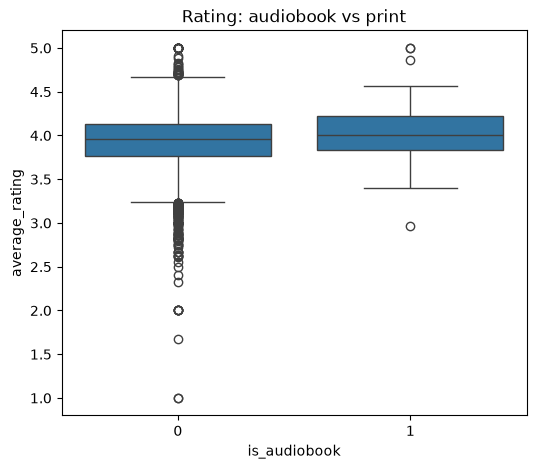

In [26]:
# Plotting average_rating by is_audiobook(where 0= printed books; 1= audiobooks)
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='is_audiobook', y='average_rating')
plt.title('Rating: audiobook vs print')
plt.show()

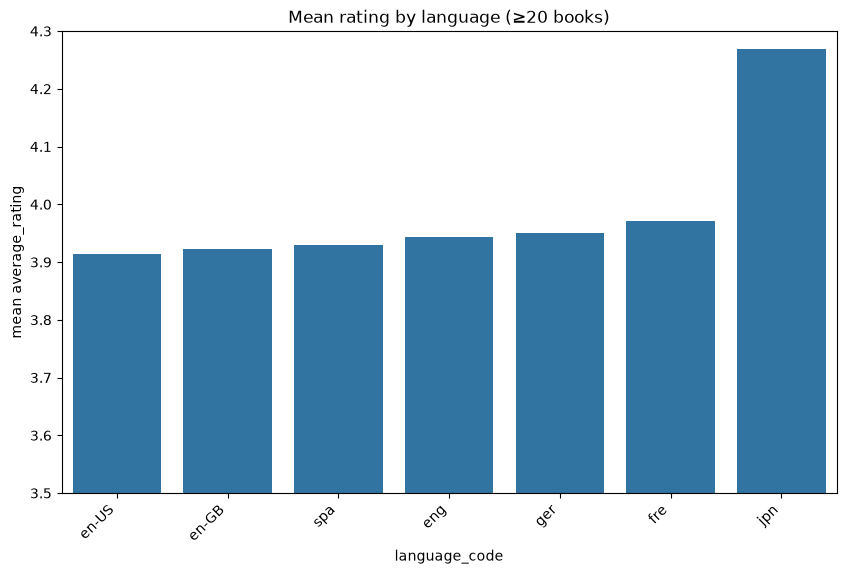

In [27]:
# Mean average_rating by language 
language_ratings = clean_books.groupby('language_code')['average_rating'].agg(['mean','count'])
language_ratings = language_ratings[language_ratings['count'] >= 20].sort_values('mean')   
plt.figure(figsize=(10,6))
sns.barplot(x=language_ratings.index, y=language_ratings['mean'])
plt.ylim(3.5, 4.3)                                       
plt.xticks(rotation=45, ha='right')
plt.title('Mean rating by language (≥20 books)'); plt.ylabel('mean average_rating')
plt.show()

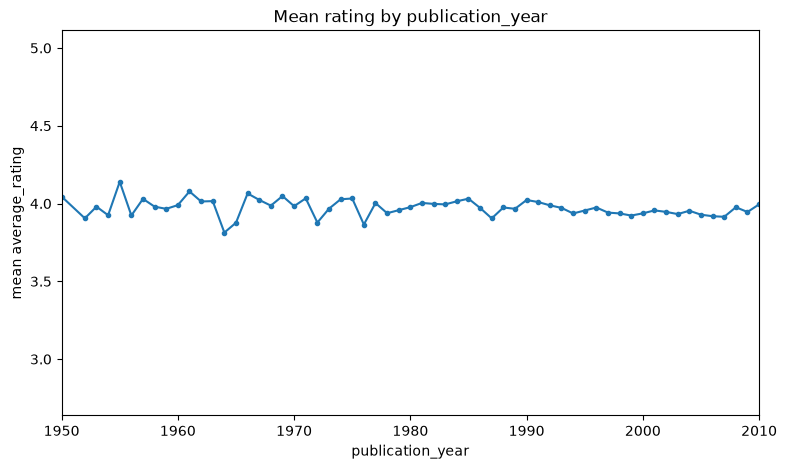

In [28]:
# Mean avarage_rating by Publication_year
# clip noisy early years
yr = clean_books.groupby('publication_year')['average_rating'].mean()
plt.figure(figsize=(9,5))
plt.plot(yr.index, yr.values, marker='.')
plt.xlim(1950, 2010)                                   
plt.title('Mean rating by publication_year')
plt.xlabel('publication_year'); plt.ylabel('mean average_rating')
plt.show()

In [29]:
#Check number of book with 0 rating_count
print("Number of books with no rating count but with an average rating:",(clean_books['ratings_count'] == 0).sum())

Number of books with no rating count but with an average rating: 55


In [30]:
#Check if those books have duplicates on title and authors
#Inconclusive results, only 4 of 55 zero_rating_count books have a sibling edition ,we will not be replacing them by their sibling rating count
zero_rating_books = clean_books.loc[clean_books['ratings_count'] == 0,['title','authors']]
result = pd.merge(clean_books, zero_rating_books, on=['title','authors'], how='inner')
len(result)

59

In [31]:
#create new column for text review per rating, replace the zero division values by 0
clean_books["rev_per_rating"]= clean_books["text_reviews_count"]/clean_books["ratings_count"]
zero_ratings_count = clean_books['ratings_count'] == 0
clean_books.loc[zero_ratings_count, "rev_per_rating"] = 0
print("inf count:", np.isinf(clean_books['rev_per_rating']).sum())
print("nan count:", clean_books['rev_per_rating'].isna().sum())
print("rev_per_rating type:",clean_books['rev_per_rating'].dtype)
clean_books[['title','text_reviews_count','ratings_count','rev_per_rating']].sample(10)

inf count: 0
nan count: 0
rev_per_rating type: float64


,title,text_reviews_count,ratings_count,rev_per_rating
8421,Collected Plays: Henry IV The Man with the Flo...,1,12,0.083333
9813,Paws Before Dying (A Dog Lover's Mystery #4),20,427,0.046838
7631,Animal Liberation,357,5325,0.067042
132,The Ravishing of Lol Stein,128,2057,0.062227
45,Uncommon Carriers,203,1630,0.124540
7896,In the Forests of the Night,508,13452,0.037764
7744,Essential Dialogues of Plato,14,4853,0.002885
1281,Sellevision,9,175,0.051429
1253,The Zanzibar Chest,172,2218,0.077547
9887,The Dogs of Riga (Kurt Wallander #2),1016,17060,0.059555


In [32]:
#Check title length per character and put it in a new column
clean_books["title_chars"] = clean_books["title"].str.len()
clean_books[['title','title_chars']].sample(10)

,title,title_chars
7535,Journal of a Novel: The East of Eden Letters,44
2853,The Stephen King Collection: Stories from Nigh...,53
10218,The Outlaws of Sherwood,23
6298,Preludes & Nocturnes (The Sandman #1),37
5587,The Camera (Ansel Adams Photography #1),39
7411,Beyond Death: The Gates of Consciousness,40
2763,Miracle Fair: Selected Poems,28
3279,Iain Banks' 'The Wasp Factory' 'The Crow Road'...,57
682,Team of Rivals: The Political Genius of Abraha...,55
9121,Ring of Fire (Ring of Fire Anthology #1),40


In [33]:
#Check title length per words and put it in a new column
clean_books["title_words"] = clean_books["title"].str.split().str.len()
clean_books[['title','title_words']].sample(10)

,title,title_words
522,Money to Burn,3
3306,The Blue and Brown Books,5
9781,Gale Gand's Short + Sweet : Quick Desserts wit...,13
6592,It's a Magical World (Calvin and Hobbes #11),8
10725,NextWave: Agents of H.A.T.E. Vol. 1: This is W...,11
7162,The Marvel Encyclopedia,3
2095,The Book of Awakening: Having the Life You Wan...,17
8485,Lolita,1
1306,Carter Beats the Devil,4
7931,Demon Rumm,2


In [34]:
# check if book is part of a collection  and create a new is_collection column
title_keyword = r'boxed set|box set|omnibus|collection|anthology'
clean_books["is_collection"] = clean_books["title"].str.contains(title_keyword, case = False).astype(int)
print("Number of books belonging to a collection:",clean_books['is_collection'].sum())
print("is_collection type:", clean_books['is_collection'].dtype)
clean_books[clean_books['is_collection']==1][['title',"is_collection"]].sample(15)

Number of books belonging to a collection: 84
is_collection type: int64


,title,is_collection
5759,The Spenser Collection: Volume I (Spenser #27-28),1
10910,Remembrance of Things Past (Boxed Set),1
10856,Firebirds Rising: An Anthology of Original Sci...,1
2404,Touch & Feel: Animals Boxed Set,1
4175,Moments of Being: A Collection of Autobiograph...,1
7159,The Art of the Personal Essay: An Anthology fr...,1
5947,The Neil Gaiman Audio Collection,1
9918,The Carl Hiaasen Collection: Lucky You and Sic...,1
4869,The Norton Anthology of Short Fiction,1
10884,The Roald Dahl Omnibus: Perfect Bedtime Storie...,1


In [35]:
#Check if book is part of a series
clean_books["is_series"] = clean_books["title"].str.contains("#").astype(int)
print("Number of books belonging to a series:",clean_books['is_series'].sum())
print("is_series type:", clean_books['is_series'].dtype)
clean_books[clean_books['is_series']==1][['title',"is_series"]].sample(15)

Number of books belonging to a series: 2379
is_series type: int64


,title,is_series
2300,Little Town on the Prairie (Little House #7),1
7424,The Search for Power (Dragonlance: Tales from ...,1
10531,Dark Lover (Black Dagger Brotherhood #1),1
9264,Doomed Queen Anne (Young Royals #3),1
9332,Warren G. Harding (The American Presidents #29),1
7079,The Eyre Affair (Thursday Next #1),1
7791,Only the River Runs Free (The Galway Chronicle...,1
1814,Four to Score (Stephanie Plum #4),1
1504,The Good Earth (House of Earth #1),1
6068,Slightly Settled (Slightly #2),1


In [36]:
#Check if book has a subtitle
clean_books["has_subtitle"] = clean_books["title"].str.contains(":").astype(int)
print("Number of books having a subtitle:",clean_books['has_subtitle'].sum())
print("has subtitles type:", clean_books['has_subtitle'].dtype)
clean_books[clean_books['has_subtitle']==1][['title',"has_subtitle"]].sample(15)

Number of books having a subtitle: 2912
has subtitles type: int64


,title,has_subtitle
3415,The Big Empty: Dialogues on Politics Sex God B...,1
7043,Abandoned Prayers: The Incredible True Story o...,1
9212,Exemplary Novels IV: Lady Cornelia the Deceitf...,1
10878,The Last Eyewitness: The Final Week,1
2456,Jamie's Dinners: The Essential Family Cookbook,1
10641,Unacknowledged Legislation: Writers in the Pub...,1
444,Euripides IV: Rhesus / The Suppliant Women / O...,1
3000,"Henry and June: From ""A Journal of Love"": The ...",1
6151,The Age of Access: The New Culture of Hypercap...,1
6446,Thus Spake the Corpse: An Exquisite Corpse Rea...,1


In [37]:
#Check number of authors
clean_books["num_authors"] = clean_books["authors"].str.count('/') + 1
print("num_authors type:", clean_books['num_authors'].dtype)
clean_books[['title','authors','num_authors']].sample(15)

num_authors type: int64


,title,authors,num_authors
10273,Prom Anonymous,Blake Nelson,1
535,Augustine: A Very Short Introduction,Henry Chadwick,1
2000,The Black Tulip,Alexandre Dumas/Robin Buss,2
5580,Le ravissement de Lol V. Stein,Marguerite Duras,1
4966,Everything and Nothing,Jorge Luis Borges/Eliot Weinberger/John M. Fei...,5
3364,The Hidden Hand,Carroll John Daly/Drew Bishop,2
8158,The Dance of Intimacy: A Woman's Guide to Cour...,Harriet Lerner,1
10982,Liturgies of the Western Church,Bard Thompson,1
4680,Christopher and His Kind,Christopher Isherwood,1
5387,Angels Don't Know Karate (The Adventures Of Th...,Debbie Dadey/Marcia Thornton Jones/John Steven...,3


In [38]:
#check if there are multiple authors
clean_books["multiple_authors"] = (clean_books["num_authors"] > 1).astype(int)
print("Books with multiple authors:",clean_books['multiple_authors'].sum())
print("multiple_authors type:", clean_books['multiple_authors'].dtype)
clean_books[clean_books['multiple_authors']==1][['title',"authors","multiple_authors"]].sample(15)

Books with multiple authors: 4552
multiple_authors type: int64


,title,authors,multiple_authors
8537,The Iliad,Homer/Andrew Lang,1
8473,October Light,John Gardner/Tom Bissell,1
7351,My Name is Aram,William Saroyan/Don Freeman,1
1205,The Pragmatic Programmer: From Journeyman to M...,Andy Hunt/Dave Thomas,1
8400,Who's To Blame (Sweet Valley High #66),Francine Pascal/Kate William,1
9588,The Art of Happiness at Work,Dalai Lama XIV/Howard C. Cutler,1
4798,Dracula,Bram Stoker/Nina Auerbach/David J. Skal,1
6527,The Painter of Modern Life and Other Essays (P...,Charles Baudelaire/Jonathon Mayne,1
7236,Le Premier homme,Albert Camus/Catherine Camus,1
1979,Never Call Retreat,Bruce Catton/E.B. Long,1


In [39]:
# check all possible languages
clean_books['language_code'].value_counts()

language_code
eng      8887
en-US    1409
spa       218
en-GB     214
fre       144
ger        99
jpn        46
mul        19
zho        14
grc        10
por        10
en-CA       7
ita         5
enm         3
lat         3
rus         2
swe         2
ara         1
nl          1
msa         1
glg         1
wel         1
nor         1
tur         1
gla         1
ale         1
Name: count, dtype: int64

In [40]:
#Build a dictionary for languages and assign it to a new column
language_groups = {
    'eng': 'english',
    'en-US': 'english',
    'en-GB': 'english',
    'en-CA': 'english',
    'spa': 'western_european',
    'fre': 'western_european',
    'ger': 'western_european',
    'por': 'western_european',
    'ita': 'western_european',
    'nl': 'western_european',
    'swe': 'western_european',
    'nor': 'western_european',
    'glg': 'western_european',
    'gla': 'western_european',
    'wel': 'western_european',
    'lat': 'classical',
    'enm': 'classical',
    'grc': 'classical',
    'jpn': 'asian', 
    'zho': 'asian', 
    'msa': 'asian',
    'rus': 'other',
    'ara': 'other',
    'tur': 'other',
      'mul': 'other',
    'ale': 'other'
}
clean_books['language_group'] = clean_books['language_code'].map(language_groups)
print("number of empty cells:", clean_books['language_group'].isna().sum())
clean_books['language_group'].value_counts()

number of empty cells: 0


language_group
english             10517
western_european      483
asian                  61
other                  24
classical              16
Name: count, dtype: int64

In [41]:
# Creating new column named Log_ratings count and Log_text_reviews count
clean_books['log_ratings'] = np.log1p(clean_books['ratings_count'])
clean_books['log_text_reviews_count'] = np.log1p(clean_books['text_reviews_count'])
clean_books[["ratings_count","log_ratings", "log_text_reviews_count","text_reviews_count"]].sample(10)
 


,ratings_count,log_ratings,log_text_reviews_count,text_reviews_count
333,297533,12.603284,9.611530,14935
10353,37,3.637586,1.791759,5
1493,54119,10.898959,7.396335,1629
9796,2447,7.803027,4.158883,63
3335,767,6.643790,4.094345,59
10650,334,5.814131,3.091042,21
5237,334,5.814131,1.098612,2
8573,5034,8.524169,5.723585,305
3031,15,2.772589,0.693147,1
8155,16897,9.734951,6.429719,619


In [42]:
# Checking ratio between number of pages and number of authors
clean_books["pages_per_author"] = clean_books["num_pages"]/clean_books["num_authors"]
clean_books["pages_per_author"].describe()

count    11101.000000
mean       262.454399
std        213.526658
min          0.000000
25%        116.000000
50%        224.000000
75%        353.000000
max       6576.000000
Name: pages_per_author, dtype: float64

In [43]:
clean_books[['num_pages','num_authors','pages_per_author']].sample(10)

,num_pages,num_authors,pages_per_author
3007,64,2,32.0
8394,32,2,16.0
10351,323,1,323.0
8866,339,1,339.0
9957,351,1,351.0
911,281,2,140.5
9488,128,2,64.0
8444,371,1,371.0
1391,144,2,72.0
3195,356,1,356.0


In [44]:
# Check if title has a number
clean_books['title_has_number'] = clean_books['title'].str.contains(r'\d').astype(int)
print("title_has_number type:", clean_books['title_has_number'].dtype)
clean_books[['title','title_has_number']].sample(10)

title_has_number type: int64


,title,title_has_number
3931,The Serpent's Shadow (Elemental Masters #1),1
9972,The King of Attolia (The Queen's Thief #3),1
4345,Billy Budd Sailor,0
7224,Nine Coaches Waiting,0
3446,Sometimes a Great Notion,0
1447,Night Over Water,0
1783,The Road to Serfdom,0
4898,The Metamorphosis,0
8186,A Wife After God's Own Heart Growth and Study ...,0
5775,Mystic River,0


In [45]:
# Count Number of Books written by authors
clean_books['author_book_count'] = clean_books.groupby('authors')['authors'].transform('count')
clean_books[['title','authors','author_book_count']].sample(10)
 

,title,authors,author_book_count
9292,Narrative of the Life of Frederick Douglass: A...,Frederick Douglass,1
5270,I Am the Messenger,Markus Zusak/Emmanuel Pailler,1
5221,The Letters of Virginia Woolf: Volume Four 192...,Virginia Woolf/Nigel Nicolson/Joanne Trautmann,2
9385,The Mill on the Floss,George Eliot,2
2555,The Secret Dreamworld of a Shopaholic (Shopaho...,Sophie Kinsella,8
10759,The King's Buccaneer (Krondor's Sons #2),Raymond E. Feist,10
2088,The Acme Novelty Datebook Vol. 1 1986-1995,Chris Ware,5
2830,Libraries,Candida Höfer/Umberto Eco,1
4815,The Feynman Lectures on Physics Vol 3,Richard P. Feynman/Robert B. Leighton/Matthew ...,3
8688,Conan and the Demons of Khitai,Akira Yoshida/Pat Lee/Paul Lee/C.B. Cebulski,1


In [46]:
# Count Number of Books published by Publishers
clean_books['publisher_book_count'] = clean_books.groupby('publisher')['publisher'].transform('count')
clean_books[['title','publisher','publisher_book_count']].sample(10)

,title,publisher,publisher_book_count
3189,The Mambo Kings Play Songs of Love,Harper Perennial,112
127,The Air-Conditioned Nightmare,New Directions,21
7585,Melliandra,Lübbe,5
708,In Cold Blood,Random House Audio,33
4334,Bacacay,Archipelago Books,1
6184,Talking Philosophy: Dialogues with Fifteen Lea...,OUP Oxford,4
3229,Sabbath's Theater,Vintage,318
10655,McSweeney's #19,McSweeney's,12
910,The Secret Garden,Children's Classics,1
2243,Little Miss Birthday,Price Stern Sloan,7


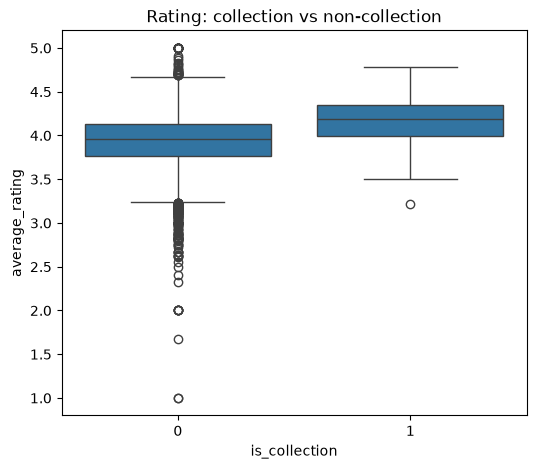

In [47]:
# Plotting average_rating by collection
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='is_collection', y='average_rating') 
plt.title('Rating: collection vs non-collection') 
plt.show()

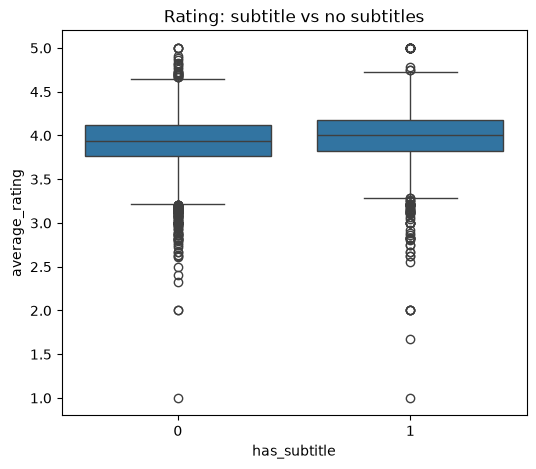

In [48]:
# Plotting average_rating by subtitles
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='has_subtitle', y='average_rating') 
plt.title('Rating: subtitle vs no subtitles') 
plt.show()

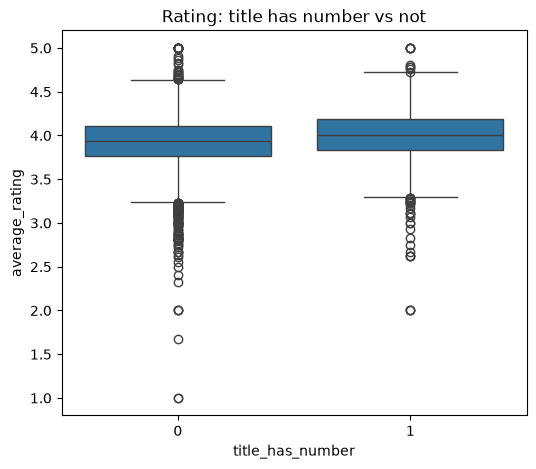

In [49]:
# Plotting average_rating by title_has_number vs not
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='title_has_number', y='average_rating') 
plt.title('Rating: title has number vs not') 
plt.show()

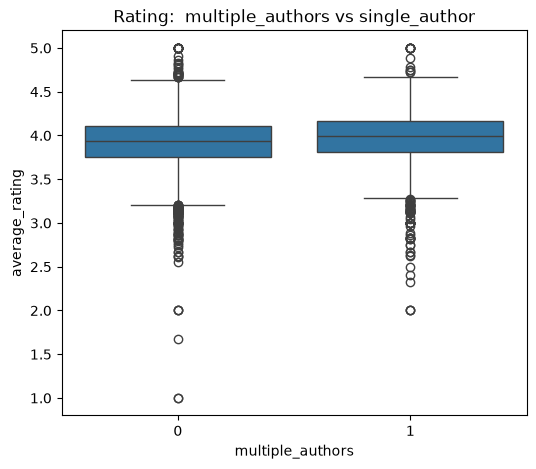

In [50]:
# Plotting average_rating by mutiple_authors 
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='multiple_authors', y='average_rating') 
plt.title('Rating:  multiple_authors vs single_author') 
plt.show()

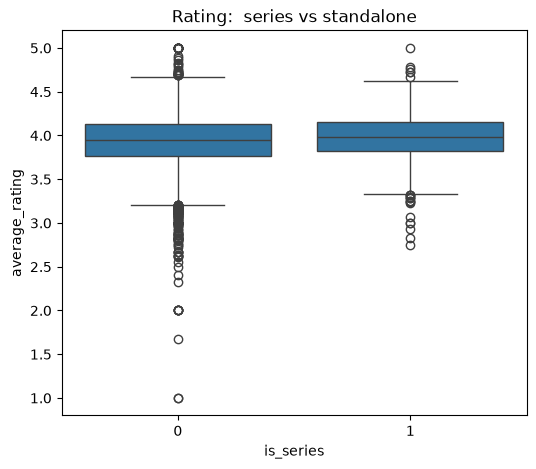

In [51]:
# Plotting average_rating by is_series
plt.figure(figsize=(6,5))
sns.boxplot(data=clean_books, x='is_series', y='average_rating') 
plt.title('Rating:  series vs standalone') 
plt.show()

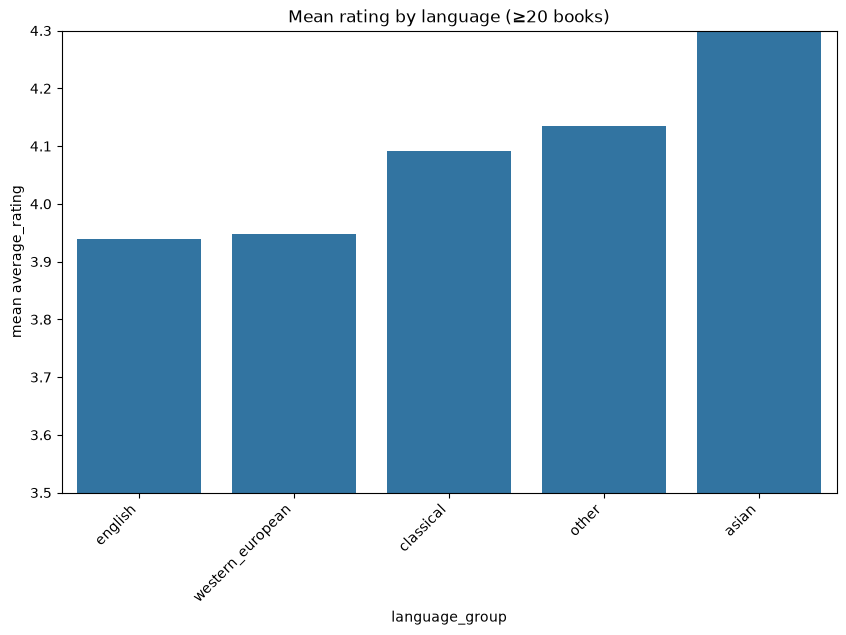

In [52]:
# Mean average_rating by language 
language_ratings = clean_books.groupby('language_group')['average_rating'].agg(['mean','count'])
language_ratings = language_ratings.sort_values('mean')   
plt.figure(figsize=(10,6))
sns.barplot(x=language_ratings.index, y=language_ratings['mean'])
plt.ylim(3.5, 4.3)                                       
plt.xticks(rotation=45, ha='right')
plt.title('Mean rating by language (≥20 books)'); plt.ylabel('mean average_rating')
plt.show()

In [53]:
#Check author book count and publisher book count to determine which plot we will use
clean_books[['author_book_count','publisher_book_count']].describe()

,author_book_count,publisher_book_count
count,11101.000000,11101.000000
mean,4.793352,47.120350
std,6.801642,70.070507
min,1.000000,1.000000
25%,1.000000,5.000000
50%,2.000000,20.000000
75%,6.000000,56.000000
max,40.000000,318.000000


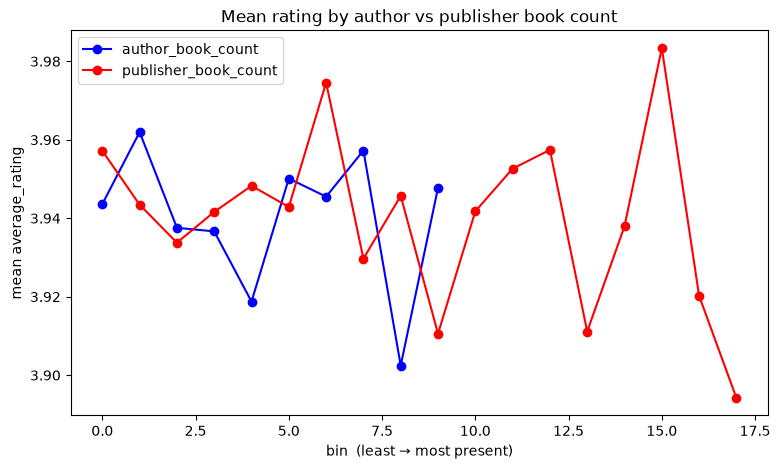

In [54]:
# Binned Plot for average_rating by author and publisher book count 
clean_books['author_count_bin'] = pd.qcut(clean_books['author_book_count'], q=20, duplicates = "drop")
clean_books['publisher_count_bin'] = pd.qcut(clean_books['publisher_book_count'], q=20, duplicates = "drop")
binned_author = clean_books.groupby('author_count_bin', observed=True)['average_rating'].mean()
binned_publisher = clean_books.groupby('publisher_count_bin', observed=True)['average_rating'].mean()
plt.figure(figsize=(9,5))
plt.plot(range(len(binned_author)), binned_author.values, marker='o', color = "blue", label = "author_book_count")
plt.plot(range(len(binned_publisher)), binned_publisher.values, marker='o', color = "red", label = "publisher_book_count")
plt.xlabel('bin  (least → most present)')
plt.ylabel('mean average_rating')
plt.title('Mean rating by author vs publisher book count')
plt.legend()
plt.show()

In [55]:
#Check title_chars column to determine which plot we will use
clean_books['title_chars'].describe()

count    11101.000000
mean        35.363391
std         23.272561
min          2.000000
25%         18.000000
50%         30.000000
75%         47.000000
max        241.000000
Name: title_chars, dtype: float64

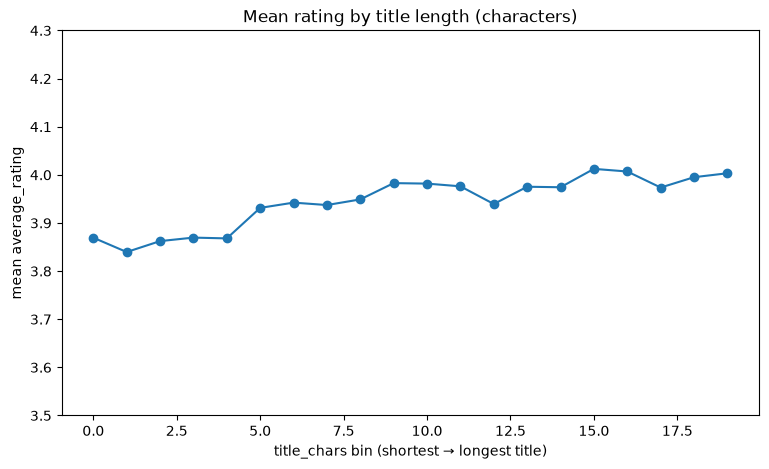

In [56]:
#Bin plot for title_chars vs rating
clean_books['title_chars_bin'] = pd.qcut(clean_books['title_chars'], q=20, duplicates='drop')
binned = clean_books.groupby('title_chars_bin', observed=True)['average_rating'].mean()
plt.figure(figsize=(9,5))
plt.plot(range(len(binned)), binned.values, marker='o')
plt.xlabel('title_chars bin (shortest → longest title)')
plt.ylabel('mean average_rating')
plt.title('Mean rating by title length (characters)')
plt.ylim(3.5, 4.3)
plt.show()

In [57]:
#Check num_author column to determine which plot we will use
clean_books['num_authors'].describe()

count    11101.000000
mean         1.729124
std          1.820268
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max         51.000000
Name: num_authors, dtype: float64

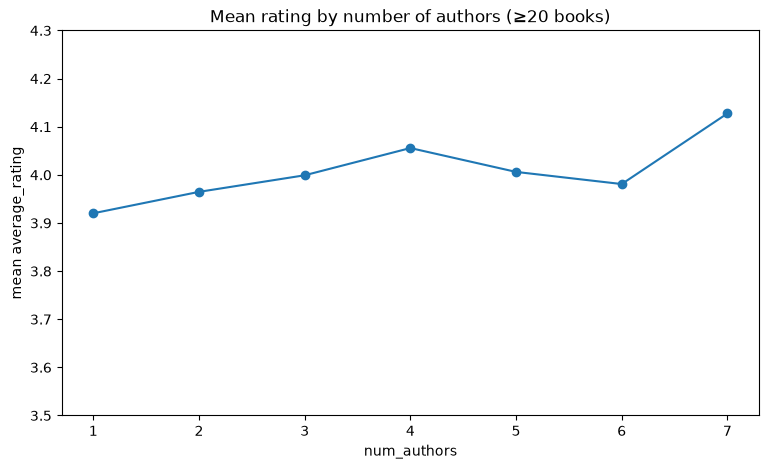

In [58]:
#Plot for num_authors vs ratings , excluding outliers with more than 20 authors
grouped = clean_books.groupby('num_authors')['average_rating'].agg(['mean','count'])
grouped = grouped[grouped['count'] >= 20]
plt.figure(figsize=(9,5))
plt.plot(grouped.index, grouped['mean'], marker='o')
plt.xlabel('num_authors')
plt.ylabel('mean average_rating')
plt.title('Mean rating by number of authors (≥20 books)')
plt.ylim(3.5, 4.3)
plt.show()

In [59]:
#Check pages_per_author column to determine which plot we will use
clean_books['pages_per_author'].describe()

count    11101.000000
mean       262.454399
std        213.526658
min          0.000000
25%        116.000000
50%        224.000000
75%        353.000000
max       6576.000000
Name: pages_per_author, dtype: float64

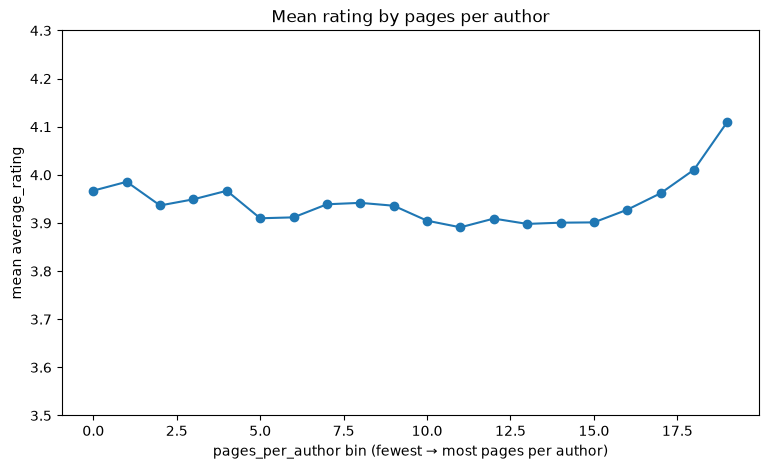

In [60]:
#Binned plot for pages_per_author vs average rating
clean_books['pages_per_author_bin'] = pd.qcut(clean_books['pages_per_author'], q=20, duplicates='drop')
binned = clean_books.groupby('pages_per_author_bin', observed=True)['average_rating'].mean()
plt.figure(figsize=(9,5))
plt.plot(range(len(binned)), binned.values, marker='o')
plt.xlabel('pages_per_author bin (fewest → most pages per author)')
plt.ylabel('mean average_rating')
plt.title('Mean rating by pages per author')
plt.ylim(3.5, 4.3)
plt.show()

In [61]:
#Check rev_per_rating column to determine which plot we will use
clean_books['rev_per_rating'].describe()

count    11101.000000
mean         0.077201
std          0.072646
min          0.000000
25%          0.032335
50%          0.061776
75%          0.103093
max          1.000000
Name: rev_per_rating, dtype: float64

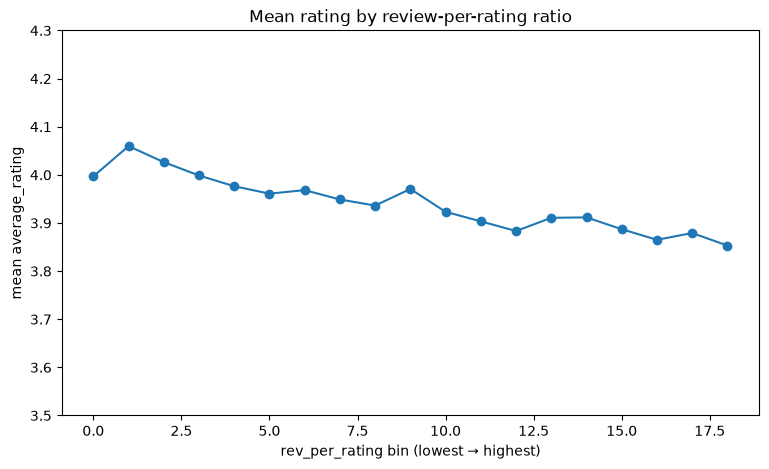

In [62]:
#Binned plot for rev_per_rating vs average rating
clean_books['rev_per_rating_bin'] = pd.qcut(clean_books['rev_per_rating'], q=20, duplicates='drop')
binned = clean_books.groupby('rev_per_rating_bin', observed=True)['average_rating'].mean()

plt.figure(figsize=(9,5))
plt.plot(range(len(binned)), binned.values, marker='o')
plt.xlabel('rev_per_rating bin (lowest → highest)')
plt.ylabel('mean average_rating')
plt.title('Mean rating by review-per-rating ratio')
plt.ylim(3.5, 4.3)
plt.show()

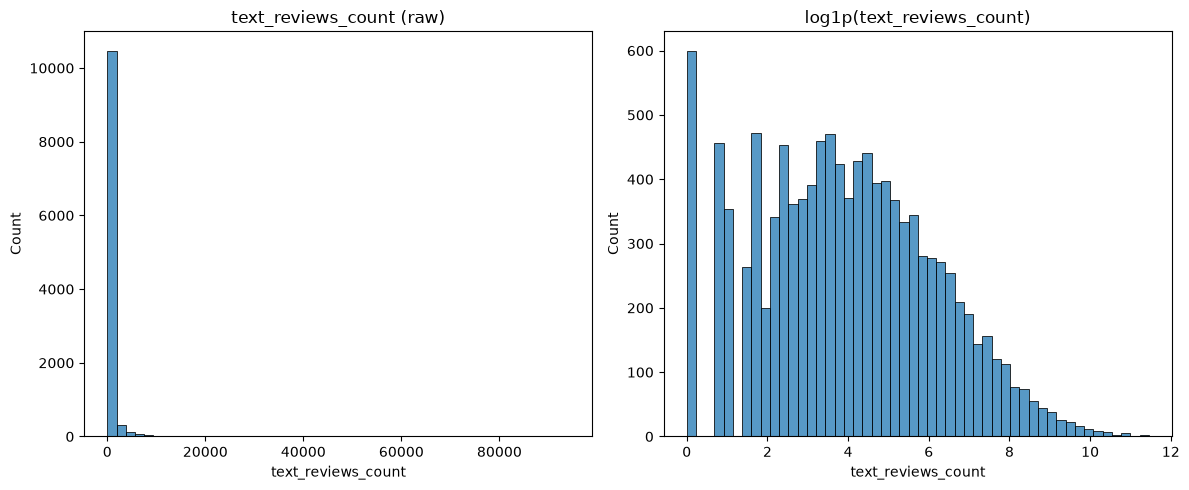

In [63]:
#raw text reviews versus log text
fig, axes = plt.subplots(1, 2, figsize=(12,5))
sns.histplot(clean_books['text_reviews_count'], bins=50, ax=axes[0])
axes[0].set_title('text_reviews_count (raw)')
sns.histplot(np.log1p(clean_books['text_reviews_count']), bins=50, ax=axes[1])
axes[1].set_title('log1p(text_reviews_count)')
plt.tight_layout(); plt.show()

In [64]:
#checking columns, some needs to be dropped
clean_books.columns.tolist()

['title',
 'authors',
 'average_rating',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publisher',
 'publication_year',
 'is_audiobook',
 'ratings_count_bin',
 'rev_per_rating',
 'title_chars',
 'title_words',
 'is_collection',
 'is_series',
 'has_subtitle',
 'num_authors',
 'multiple_authors',
 'language_group',
 'log_ratings',
 'log_text_reviews_count',
 'pages_per_author',
 'title_has_number',
 'author_book_count',
 'publisher_book_count',
 'author_count_bin',
 'publisher_count_bin',
 'title_chars_bin',
 'pages_per_author_bin',
 'rev_per_rating_bin']

In [65]:
#dropping bin columns, they were aids for plotting
clean_books = clean_books.drop(columns=['ratings_count_bin','title_chars_bin','pages_per_author_bin','rev_per_rating_bin','author_count_bin','publisher_count_bin'])
clean_books.columns.tolist()

['title',
 'authors',
 'average_rating',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publisher',
 'publication_year',
 'is_audiobook',
 'rev_per_rating',
 'title_chars',
 'title_words',
 'is_collection',
 'is_series',
 'has_subtitle',
 'num_authors',
 'multiple_authors',
 'language_group',
 'log_ratings',
 'log_text_reviews_count',
 'pages_per_author',
 'title_has_number',
 'author_book_count',
 'publisher_book_count']

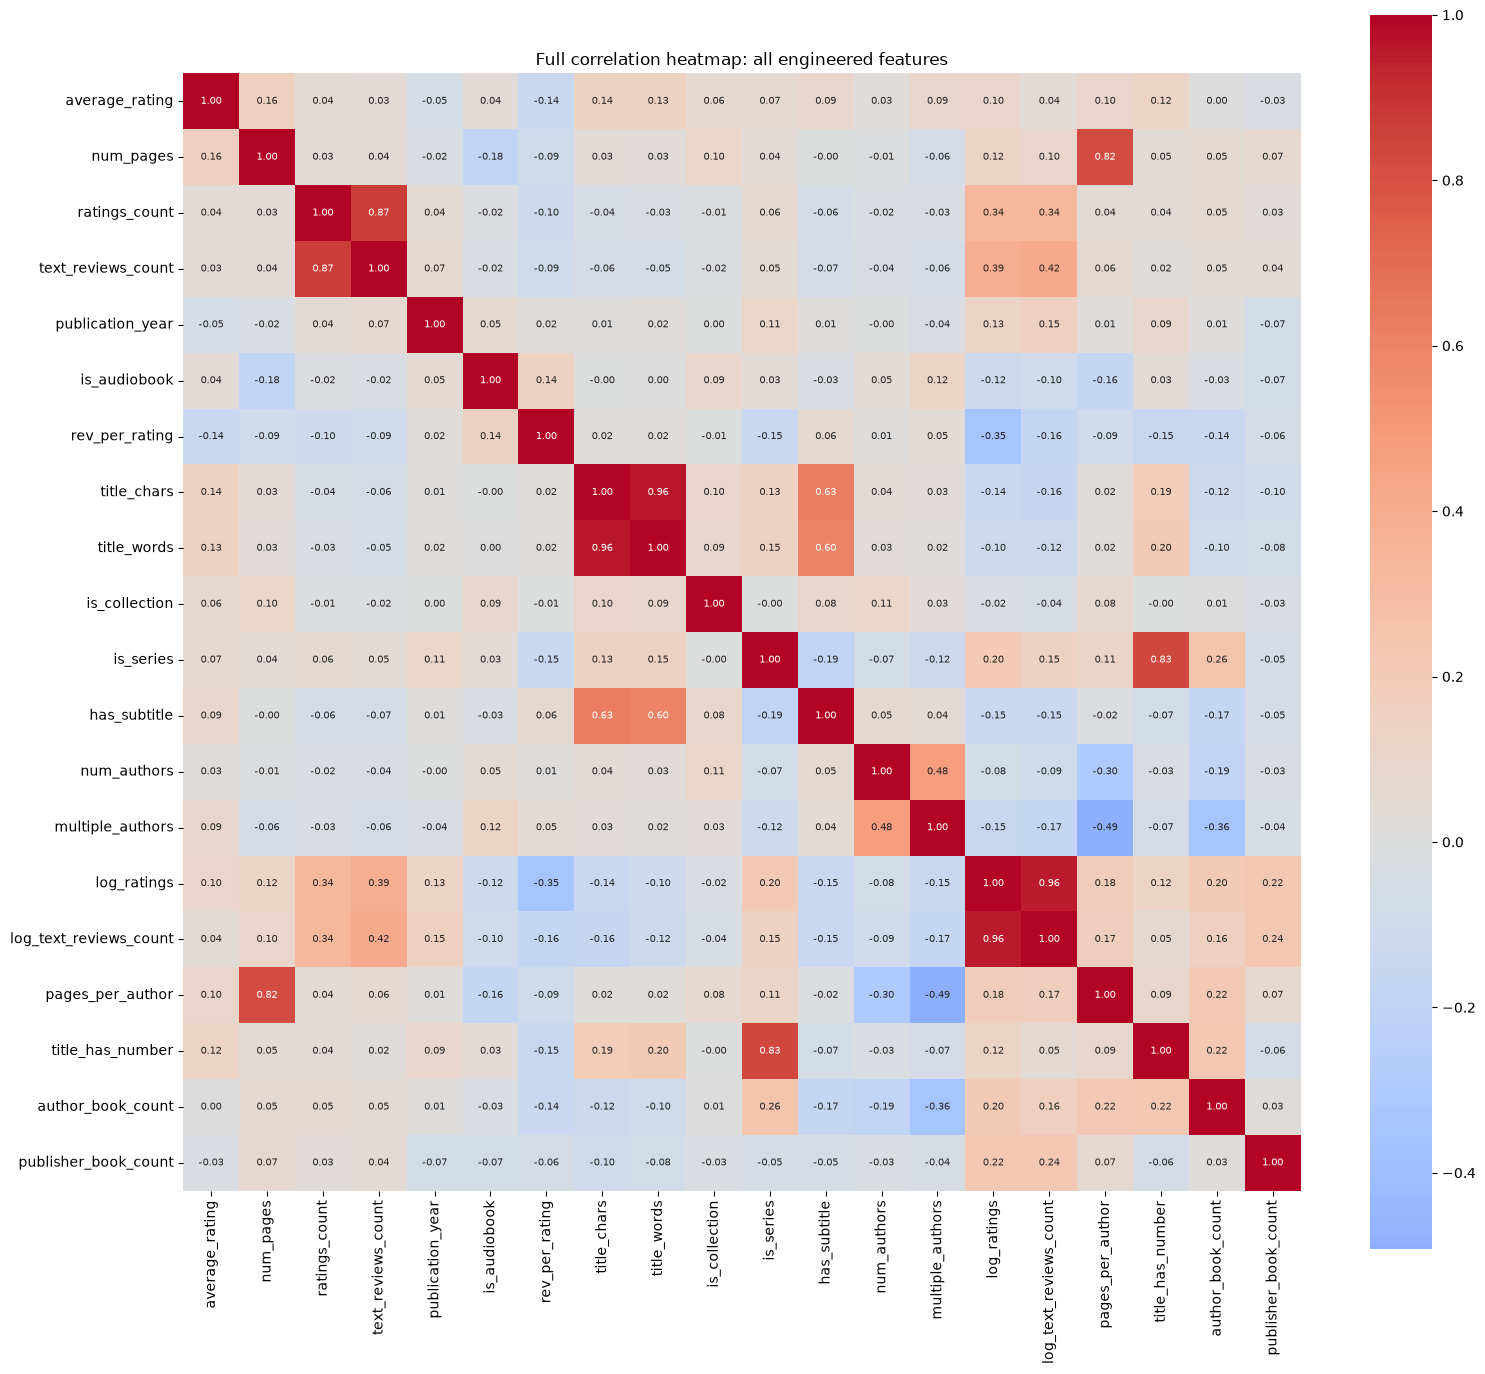

In [66]:
#full heatmap with new features
num_cols = ['average_rating', 'num_pages', 'ratings_count', 'text_reviews_count',
            'publication_year', 'is_audiobook', 'rev_per_rating', 'title_chars',
            'title_words', 'is_collection', 'is_series', 'has_subtitle', 'num_authors',
            'multiple_authors', 'log_ratings', 'log_text_reviews_count', 'pages_per_author',
            'title_has_number', 'author_book_count', 'publisher_book_count']

plt.figure(figsize=(16,14))
sns.heatmap(clean_books[num_cols].corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True, annot_kws={'size':7})
plt.title('Full correlation heatmap: all engineered features')
plt.tight_layout()
plt.show()

In [67]:
#dropping redundunt features or weak correlations 
clean_books = clean_books.drop(columns=['title_words','is_series','author_book_count','publisher_book_count','log_text_reviews_count'])
clean_books.columns.tolist()

['title',
 'authors',
 'average_rating',
 'language_code',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publisher',
 'publication_year',
 'is_audiobook',
 'rev_per_rating',
 'title_chars',
 'is_collection',
 'has_subtitle',
 'num_authors',
 'multiple_authors',
 'language_group',
 'log_ratings',
 'pages_per_author',
 'title_has_number']

In [68]:
#group authors and publisher and do a frequency encoding
clean_books['author_freq'] = clean_books.groupby('authors')['authors'].transform('count')
clean_books['publisher_freq'] = clean_books.groupby('publisher')['publisher'].transform('count')
clean_books[['title','authors','author_freq','publisher','publisher_freq']].sample(10)

,title,authors,author_freq,publisher,publisher_freq
6495,Fargo Rock City: A Heavy Metal Odyssey in Rura...,Chuck Klosterman,5,Scribner,73
2020,Essentials of Conservation Biology,Richard B. Primack,1,Sinauer Associates,1
5050,Beyond Good and Evil: Prelude to a Philosophy ...,Friedrich Nietzsche/Walter Kaufmann,1,Vintage,318
3429,Book of Dreams,Jack Kerouac/Robert Creeley,1,City Lights Publishers,6
10002,The Abyss,Orson Scott Card/James Francis Cameron,1,Legend,1
175,The Crying of Lot 49,Thomas Pynchon,10,Harper Perennial,112
4224,Gentlemen and Players,Joanne Harris,7,William Morrow,28
6730,Reason in History,Georg Wilhelm Friedrich Hegel/Robert S. Hartman,1,Pearson,14
84,eBay Business All-in-One Desk Reference for Du...,Marsha Collier,4,Wiley,22
9509,Forever . . .,Judy Blume,8,Pan Childrens,1


In [69]:
#create dictionary to be used for building the webapp
author_freq_map = clean_books['authors'].value_counts().to_dict()
publisher_freq_map = clean_books['publisher'].value_counts().to_dict()

In [70]:
#Ordinal encoding  for authors and publishers
#Note: ordinal encoding treats exact author-string combinations as distinct categories, 
#so co-authored books aren't linked to their individual authors' solo works. 
#Same limitation as our earlier author_book_count feature; not fixed for the same reasons (added complexity, limited expected payoff).
enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
clean_books[['author_ord','publisher_ord']] = enc.fit_transform(clean_books[['authors','publisher']].fillna('missing'))
clean_books[['title','authors','author_ord','publisher','publisher_ord']].sample(10)

,title,authors,author_ord,publisher,publisher_ord
6934,Good Grief: The Story of Charles M. Schulz,Rheta Grimsley Johnson,5102.0,Pharos Books,1515.0
10262,The Economics of Innocent Fraud: Truth for Our...,John Kenneth Galbraith,3160.0,Houghton Mifflin Harcourt,982.0
5137,The Summit (Everest #3),Gordon Korman,2154.0,Scholastic Paperbacks,1758.0
9618,The Ring Volume 4 Birthday,Kōji Suzuki/Sakura Mizuki,3621.0,Dark Horse Manga,503.0
10120,Ports of Call,Jack Vance,2663.0,Tor Books,1991.0
10280,My Side of the Mountain (Mountain #1),Jean Craighead George,2895.0,Puffin Books,1609.0
7772,Notebooks of the Mind: Explorations of Thinkin...,Vera John-Steiner,6209.0,Oxford University Press USA,1424.0
2333,Dead Cert,Dick Francis,1395.0,G.P. Putnam's Sons,743.0
3681,The Odes and Selected Fragments,Pindar/G.S. Conway/Richard Stoneman,4966.0,Everyman's Library,651.0
9836,Hit Parade (John Keller #3),Lawrence Block,3700.0,William Morrow,2196.0


In [71]:
#one hot encoding for our language_group column to get binary values
clean_books = pd.get_dummies(clean_books, columns=['language_group'], dtype=int)
clean_books.filter(like='language_group').head(10)

,language_group_asian,language_group_classical,language_group_english,language_group_other,language_group_western_european
0,0,0,1,0,0
1,0,0,1,0,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,1,0,0
5,0,0,1,0,0
6,0,0,1,0,0
7,0,0,1,0,0
8,0,0,1,0,0
9,0,0,1,0,0


In [72]:
#create new csv with all feature engineering and text remaining
clean_books.to_csv("../Data/Processed/clean_books_with_text.csv", index=False)

In [73]:
#dropping the last text columns
clean_books = clean_books.drop(columns=['title','authors','publisher','language_code'])


In [74]:
clean_books.columns.tolist()

['average_rating',
 'num_pages',
 'ratings_count',
 'text_reviews_count',
 'publication_year',
 'is_audiobook',
 'rev_per_rating',
 'title_chars',
 'is_collection',
 'has_subtitle',
 'num_authors',
 'multiple_authors',
 'log_ratings',
 'pages_per_author',
 'title_has_number',
 'author_freq',
 'publisher_freq',
 'author_ord',
 'publisher_ord',
 'language_group_asian',
 'language_group_classical',
 'language_group_english',
 'language_group_other',
 'language_group_western_european']

In [75]:
#Dropping rating_count and text_reviews_count  because of redunduncy with log versions
clean_books = clean_books.drop(columns=['ratings_count','text_reviews_count'])
clean_books.columns.tolist()

['average_rating',
 'num_pages',
 'publication_year',
 'is_audiobook',
 'rev_per_rating',
 'title_chars',
 'is_collection',
 'has_subtitle',
 'num_authors',
 'multiple_authors',
 'log_ratings',
 'pages_per_author',
 'title_has_number',
 'author_freq',
 'publisher_freq',
 'author_ord',
 'publisher_ord',
 'language_group_asian',
 'language_group_classical',
 'language_group_english',
 'language_group_other',
 'language_group_western_european']

In [76]:
#Drop average_rating and split our data into training and test
X = clean_books.drop(columns=['average_rating'])
y = clean_books['average_rating']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("Size of training set:",X_train.shape)
print("Size of test set:",X_test.shape)

Size of training set: (8880, 21)
Size of test set: (2221, 21)


In [77]:
#Linear regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](21,)","[ 0. ,-0. , 0.15,...,-0.13,-0.02,-0.08]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](21,)","['num_pages','publication_year','is_audiobook',..., 'language_group_english','language_group_other', 'language_group_western_european']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,8.84
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,21
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(20)


In [78]:
#result with linear regression
y_pred = lin_reg.predict(X_test)
print(f"Linear Regression — R2: {r2_score(y_test, y_pred):.3f}  MAE: {mean_absolute_error(y_test, y_pred):.3f}")

Linear Regression — R2: 0.132  MAE: 0.211


In [79]:
#Random forest model ( some feature were not necessarily linear and this model would help us improve our project)
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)
print(f"Random Forest — R2: {r2_score(y_test, y_pred_rf):.3f}  MAE: {mean_absolute_error(y_test, y_pred_rf):.3f}")

Random Forest — R2: 0.172  MAE: 0.198


In [80]:
# Gradient Boosting  model , very little improvement over linear regression
gb_model = GradientBoostingRegressor(n_estimators=200, random_state=42)
gb_model.fit(X_train, y_train)
y_pred_gb = gb_model.predict(X_test)
print(f"Gradient Boosting — R2: {r2_score(y_test, y_pred_gb):.3f}  MAE: {mean_absolute_error(y_test, y_pred_gb):.3f}")

Gradient Boosting — R2: 0.131  MAE: 0.202


In [81]:
#Cross validation using our best model, the random forest
from sklearn.model_selection import cross_val_score
cv_scores = cross_val_score(rf_model, X, y, cv=5, scoring='r2')
print("CV R2 scores:", cv_scores)
print("Mean CV R2:", cv_scores.mean())
print("Std CV R2:", cv_scores.std())

CV R2 scores: [0.15475233 0.12941749 0.15498448 0.13149241 0.08836934]
Mean CV R2: 0.13180320914968593
Std CV R2: 0.024315932071551236


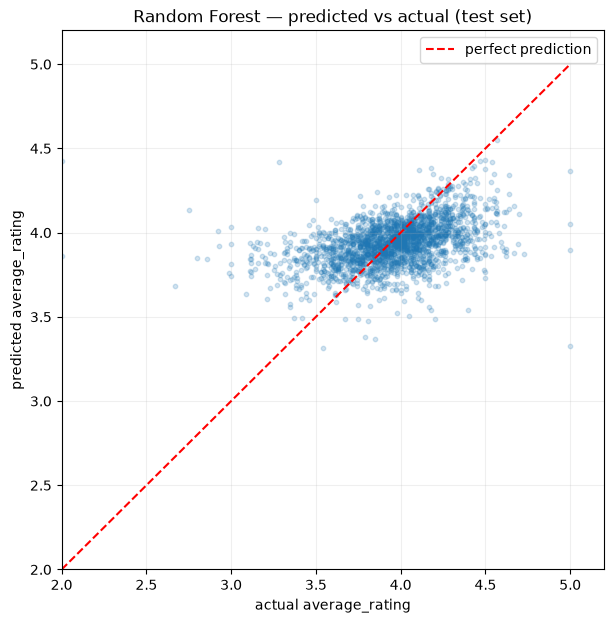

In [82]:
#Predicted vs actual on the test set
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred_rf, alpha=0.2, s=10)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', label='perfect prediction')
plt.xlabel('actual average_rating')
plt.ylabel('predicted average_rating')
plt.title('Random Forest — predicted vs actual (test set)')
plt.legend()
plt.xlim(2, 5.2)
plt.ylim(2, 5.2)
plt.grid(alpha=0.2)
plt.show()

In [83]:
#Check feature importance and compare it to our correlation heatmap
importances = pd.Series(rf_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances)

log_ratings                        0.125447
num_pages                          0.123688
rev_per_rating                     0.117782
publisher_ord                      0.114739
title_chars                        0.103441
author_ord                         0.101693
pages_per_author                   0.079960
publication_year                   0.071015
publisher_freq                     0.067134
author_freq                        0.044351
num_authors                        0.014027
title_has_number                   0.010967
has_subtitle                       0.009017
multiple_authors                   0.003893
language_group_english             0.003732
language_group_asian               0.002939
language_group_western_european    0.002242
is_audiobook                       0.001759
language_group_classical           0.000978
is_collection                      0.000803
language_group_other               0.000393
dtype: float64


In [84]:
#fit our random forest mdoel to the entire data set as it is the model we will keep
final_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
final_model.fit(X, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"m

In [85]:
#create the model, compress it to fit in the github later
import joblib

model_bundle = {
    'model': final_model,
    'ordinal_encoder': enc,
    'language_groups': language_groups,
    'feature_columns': X.columns.tolist(),
    'author_freq_map': author_freq_map,
    'publisher_freq_map': publisher_freq_map,
}

joblib.dump(model_bundle, "../Model/book_rating_random_forest_model.joblib", compress=('xz', 3))

['../Model/book_rating_random_forest_model.joblib']

In [86]:
#check path of created model
import os
print(os.getcwd())

c:\Users\abdel\Documents\GitHub\ML_PROJECT_DSTI\Notebooks


In [87]:
#new dataset with only book features
clean_books.to_csv("../Data/Processed/clean_books_features.csv", index=False)